# <center> **Tarea 1** </center>

1. Proponer entre 4 y 5 distribuciones de probabilidad para modelar los datos de una variable seleccionada.
2. Para cada distribución, realizar las siguientes gráficas:
   - **QQ-Plot:** Comparar los cuantiles teóricos y empíricos.
   - **PP-Plot:** Comparar la función de distribución acumulada (CDF) teórica y empírica.
   - **Contraste entre densidades:** Graficar la densidad teórica superpuesta a la densidad empírica.
   - **Contraste entre CDF:** Comparar la función de distribución acumulada teórica y empírica.
3. Determinar la distribución que mejor se ajuste a los datos utilizando el p-valor del test de Kolmogorov-Smirnov.

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as sps
import numpy as np
import pandas as pd


In [3]:
data = df = pd.read_csv('../Dataset/data_aula04.csv', header=0, sep=';')
print(data.head())

   var1       var2      var3   var4     var5
0     2   0.031616  3.809430   6.09   7200.0
1     2  -0.000553  3.697720  12.46   7200.0
2     3   0.058933  3.879095  17.79  72800.0
3     2   0.000243  3.793765  32.07  16800.0
4     1  82.699796  3.969103  30.31  84800.0


In [4]:
def ecdf(a):
    x, counts = np.unique(a, return_counts=True)
    cusum = np.cumsum(counts)
    return x, cusum / cusum[-1]

In [5]:

# Función para graficar el contraste entre las distribuciones
def plot_distribution_comparison(data, dist_name, ax_row):
    dist = getattr(sps, dist_name)
    
    # Ajuste de la distribución
    params = dist.fit(data)
    
    # QQ-Plot
    ax_row[0].cla()
    sps.probplot(data, dist=dist_name, sparams=params, plot=ax_row[0])
    ax_row[0].set_title(f'QQ-Plot ({dist_name})')
    
    # PP-Plot
    x_empirical, y_empirical = ecdf(data)
    y_theoretical = dist.cdf(x_empirical, *params)
    
    ax_row[1].cla()
    ax_row[1].plot(x_empirical, y_empirical, label='Empirical CDF')
    ax_row[1].plot(x_empirical, y_theoretical, label=f'Theoretical CDF ({dist_name})', linestyle='--')
    ax_row[1].legend()
    ax_row[1].set_title(f'PP-Plot ({dist_name})')

    x = np.linspace(min(data), max(data), 1000)
    
    ax_row[2].cla()
    sns.kdeplot(data, label='Empirical Density', ax=ax_row[2])
    ax_row[2].plot(x, dist.pdf(x, *params), label=f'{dist_name} PDF', linestyle='--')
    ax_row[2].legend()
    ax_row[2].set_title(f'Densidad Empírica vs Teórica ({dist_name})')

    ax_row[3].cla()
    ax_row[3].plot(x_empirical, y_empirical, label='Empirical CDF', linestyle='-')
    ax_row[3].plot(x_empirical, y_theoretical, label=f'Theoretical CDF ({dist_name})', linestyle='--')
    ax_row[3].legend()
    ax_row[3].set_title(f'CDF Empírica vs Teórica ({dist_name})')


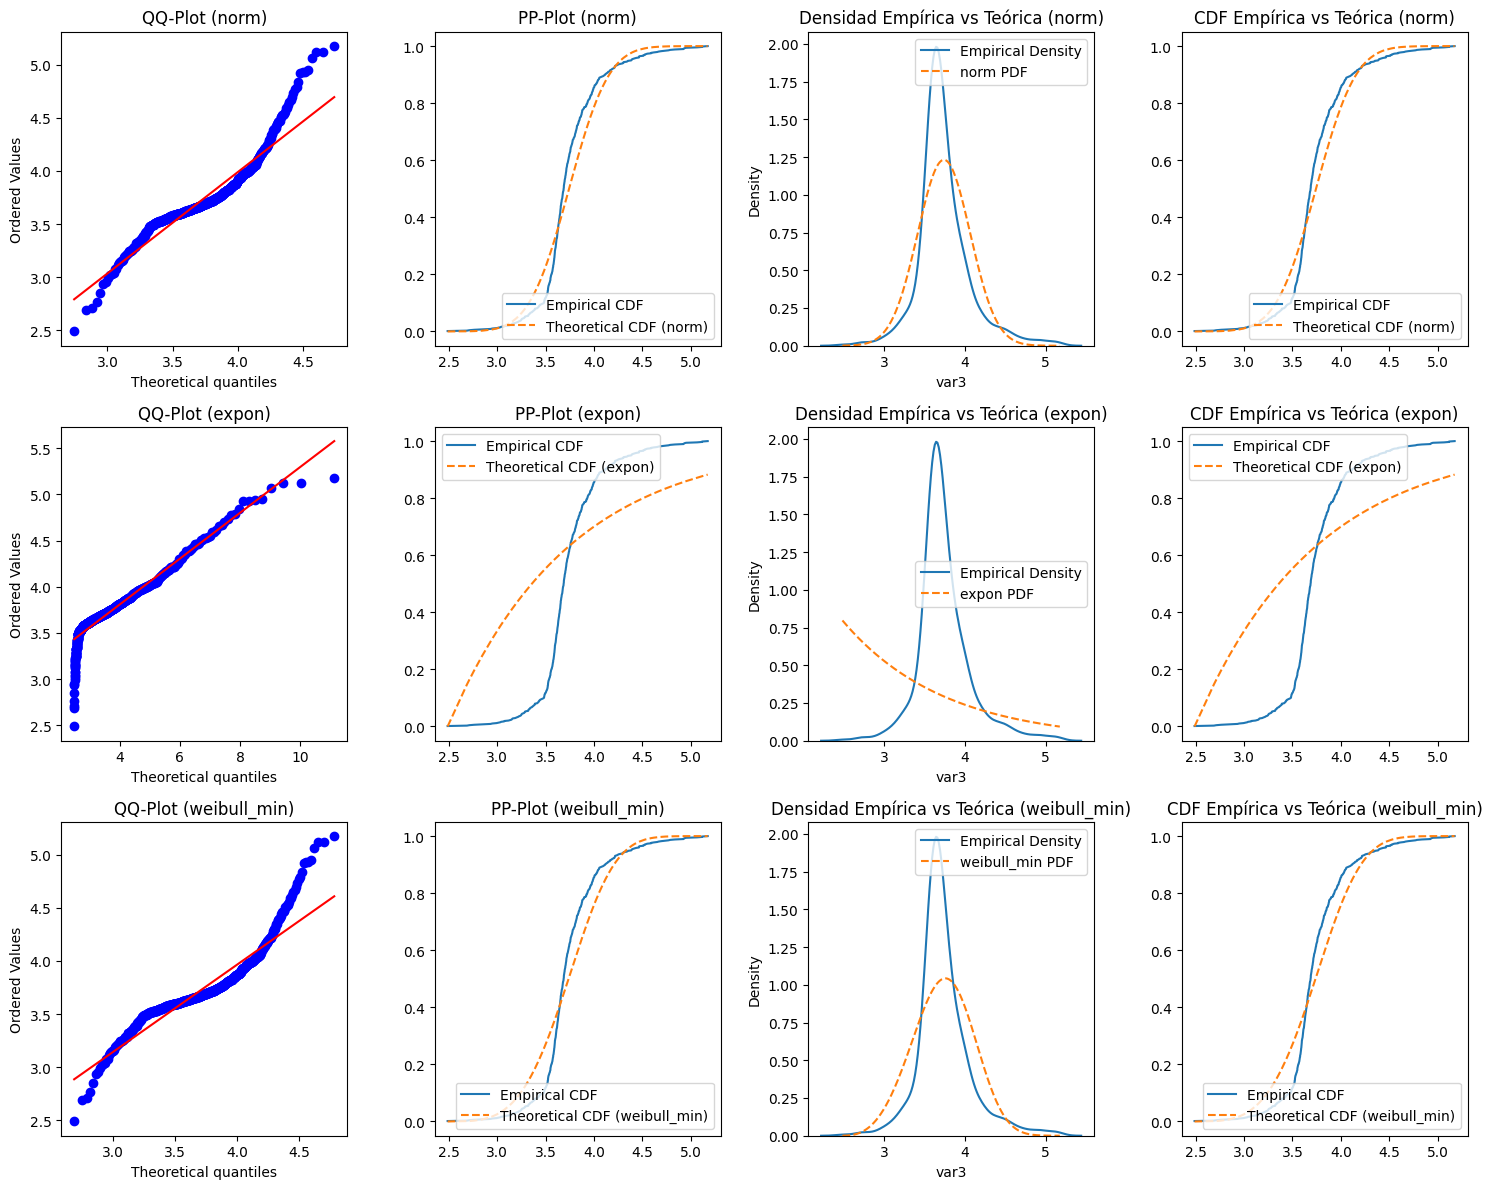

In [6]:
# Definir las distribuciones a ajustar (por ejemplo, normal, exponencial, Weibull)
dist_names = ['norm', 'expon', 'weibull_min']

# Crear una cuadrícula de 3x4 para mostrar todos los gráficos
fig, ax = plt.subplots(3, 4, figsize=(15, 12))

# Graficar para var1
plot_distribution_comparison(data['var1'], 'norm', ax[0, :])
plot_distribution_comparison(data['var1'], 'expon', ax[1, :])
plot_distribution_comparison(data['var1'], 'weibull_min', ax[2, :])

# Graficar para var2
plot_distribution_comparison(data['var2'], 'norm', ax[0, :])
plot_distribution_comparison(data['var2'], 'expon', ax[1, :])
plot_distribution_comparison(data['var2'], 'weibull_min', ax[2, :])

# Graficar para var3
plot_distribution_comparison(data['var3'], 'norm', ax[0, :])
plot_distribution_comparison(data['var3'], 'expon', ax[1, :])
plot_distribution_comparison(data['var3'], 'weibull_min', ax[2, :])

plt.tight_layout()
plt.show()

In [7]:
def get_best_distribution(data, dist_names):
    dist_results = []
    params = {}
    
    for dist_name in dist_names:
        dist = getattr(sps, dist_name)
        param = dist.fit(data)
        params[dist_name] = param
        
        # Kolmogorov-Smirnov test
        D, p = sps.kstest(data, dist_name, args=param)
        print(f'P-value para: {dist_name}: {p}')
        dist_results.append((dist_name, p))
    
    # Mejor distribución
    best_dist, best_p = max(dist_results, key=lambda item: item[1])
    print(f'\nLa mejor distribucion: {best_dist} con un P-value de: {best_p}')
    
    return best_dist, params[best_dist]

In [8]:
dist_names = ['norm', 'expon', 'weibull_min', 'lognorm', 'gamma']
best_dist, best_params = get_best_distribution(data['var1'], dist_names)

P-value para: norm: 1.389603503708046e-57
P-value para: expon: 4.680781040176398e-99
P-value para: weibull_min: 4.490109192124491e-193
P-value para: lognorm: 2.3065901296622204e-55
P-value para: gamma: 8.329031930962025e-54

La mejor distribucion: gamma con un P-value de: 8.329031930962025e-54


C:\Users\Paco\AppData\Roaming\Python\Python312\site-packages\scipy\stats\_continuous_distns.py:6626: RuntimeWarning: overflow encountered in divide
  return np.sum((1 + np.log(shifted/scale)/shape**2)/shifted)
